Procrustes analysis 
Aims to align 2 sets of points (in other words, 2 shapes) to minimize square distance between them by removing scale, translation and rotation warp components.

In [51]:
import numpy as np


def procrustes(X, Y, scaling=True, reflection='best'):
    """
    """

    n,m = X.shape
    ny,my = Y.shape

    muX = X.mean(0)
    muY = Y.mean(0)

    X0 = X - muX
    Y0 = Y - muY

    ssX = (X0**2.).sum()
    ssY = (Y0**2.).sum()
    print(ssX)
    print(ssY)

    # centred Frobenius norm
    normX = np.sqrt(ssX)
    normY = np.sqrt(ssY)

    # scale to equal (unit) norm
    X0 /= normX
    Y0 /= normY

    if my < m:
        Y0 = np.concatenate((Y0, np.zeros(n, m-my)),0)

    # optimum rotation matrix of Y
    A = np.dot(X0.T, Y0)
    U,s,Vt = np.linalg.svd(A,full_matrices=False)
    V = Vt.T
    T = np.dot(V, U.T)

    if reflection != 'best':

        # does the current solution use a reflection?
        have_reflection = np.linalg.det(T) < 0

        # if that's not what was specified, force another reflection
        if reflection != have_reflection:
            V[:,-1] *= -1
            s[-1] *= -1
            T = np.dot(V, U.T)

    traceTA = s.sum()

    if scaling:

        # optimum scaling of Y
        b = traceTA * normX / normY

        # standarised distance between X and b*Y*T + c
        d = 1 - traceTA**2
        # transformed coords
        Z = normX*traceTA*np.dot(Y0, T) + muX

    else:
        b = 1
        d = 1 + ssY/ssX - 2 * traceTA * normY / normX
        Z = normY*np.dot(Y0, T) + muX

    # transformation matrix
    if my < m:
        T = T[:my,:]
    c = muX - b*np.dot(muY, T)
    #rot =1
    #scale=2
    #translate=3
    #transformation values 
    tform = {'rotation':T, 'scale':b, 'translation':c}

    return d, Z, tform

In [52]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.cm as cm 
import cv2
import imageio
import scipy.ndimage as ndi

In [53]:
ct = cv2.imread('jpg/ct.jpg', 0)

In [54]:
ct_points=[]
mri_points=[]

Specify the number of points

In [55]:
n=int(input())

In [56]:
# Define Click Function
def click_event_ct(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        print(x,y)
        ct_points.append([x,y])

In [57]:
cv2.imshow('Image CT', ct)

cv2.setMouseCallback('Image CT', click_event_ct)

cv2.waitKey(0)#press any key to close all windows
cv2.destroyAllWindows()

ct_points

201 243
254 179
239 327
303 251
267 225


[[201, 243], [254, 179], [239, 327], [303, 251], [267, 225]]

In [58]:
# Define Click Function
def click_event_mri(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        print(x,y)
        mri_points.append([x,y])

In [59]:
mri_registered = cv2.imread('jpg/mri.jpg',0)

cv2.imshow('Image MRI', mri_registered)
cv2.setMouseCallback('Image MRI', click_event_mri)

cv2.waitKey(0)#press any key to close all windows
cv2.destroyAllWindows()

mri_points

129 274
281 78
244 461
412 277
315 207


[[129, 274], [281, 78], [244, 461], [412, 277], [315, 207]]

#### Specifying the co-ordinates

In [60]:
X_pts = np.asarray(ct_points)
Y_pts = np.asarray(mri_points)
print(X_pts)

[[201 243]
 [254 179]
 [239 327]
 [303 251]
 [267 225]]


In [61]:
d,Z_pts,Tform = procrustes(X_pts,Y_pts)

17116.8
119492.0


In [62]:
R = np.eye(3)

In [63]:
Tform

{'rotation': array([[ 0.99975758,  0.02201759],
        [-0.02201759,  0.99975758]]),
 'scale': 0.37728156409204366,
 'translation': array([150.77488535, 144.86253975])}

In [64]:
R[0:2,0:2] = Tform['rotation']

In [65]:
S = np.eye(3) * Tform['scale'] 
S[2,2] = 1
t = np.eye(3)
t[0:2,2] = Tform['translation']
M = np.dot(np.dot(R,S),t.T).T
h=ct.shape[0]
w=ct.shape[1]
tr_Y_img = cv2.warpAffine(mri_registered,M[0:2,:],(h,w))
cv2.imwrite("jpg/mri_registered.jpg", tr_Y_img) 

True

In [66]:
aY_pts = np.hstack((Y_pts,np.array(([[1,1,1,1,1]])).T))
tr_Y_pts = np.dot(M,aY_pts.T).T

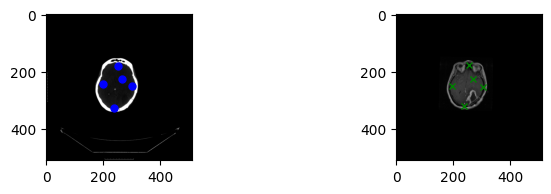

In [67]:
plt.figure() 
plt.subplot(1,3,1)
plt.imshow(ct,cmap=cm.gray)
plt.plot(X_pts[:,0],X_pts[:,1],'bo',markersize=5)
# plt.axis('off')
# plt.subplot(1,3,2)
# plt.imshow(mri_registered,cmap=cm.gray)
# plt.plot(Y_pts[:,0],Y_pts[:,1],'ro',markersize=5)
# plt.axis('off')
plt.subplot(1,3,3)
# plt.imshow(ct_fixed,cmap=cm.gray)
plt.imshow(tr_Y_img,cmap=cm.gray)
# plt.plot(X_pts[:,0],X_pts[:,1],'bo',markersize=5) 
# plt.plot(Z_pts[:,0],Z_pts[:,1],'ro',markersize=5)
plt.plot(tr_Y_pts[:,0],tr_Y_pts[:,1],'gx',markersize=5)
# plt.axis('off')
plt.show()